# Assignment 4 (new data) — 2. Rice images (CNN)

**One learning problem, three implementations: NumPy from scratch, TensorFlow/Keras, and PyTorch.**

| # | Dataset | Structure | Model family |
|---|---------|-----------|--------------|
| A | BRFSS diabetes | tabular, 19 features | MLP |
| **B** | **Rice Image Dataset** | **image, 3×32×32** | **CNN** |
| C | Intel scenes | image, 3×64×64 | CNN |

75,000 photographs of single rice grains, 15,000 each of five varieties — Arborio, Basmati, Ipsala,
Jasmine and Karacadag — on a black background. The classes are **perfectly balanced**, which makes this
the exact opposite of notebook 01 and means accuracy is a trustworthy metric here.

### Why a CNN this time

Notebook 01 used an MLP because a tabular row has no spatial neighbourhood. An image does, and
`theory_notes.md` §2.1 puts numbers on what that buys. Flattening a 32×32×3 grain into a 3,072-vector and
feeding a 1,024-unit dense layer would cost

$$3072 \times 1024 + 1024 \approx 3.15 \text{ million parameters — in the first layer alone}$$

and would still destroy the fact that neighbouring pixels belong to the same edge. The CNN below solves the
whole problem with **544,453** parameters, and 96 % of *those* sit in the flatten-then-dense head rather
than in the convolutions.

Convolution earns its place here for the three reasons §2.1 lists: far fewer parameters through weight
sharing, preserved spatial structure, and tolerance to a grain sitting a few pixels off centre.

### Why 32×32

The originals are 250×250. What distinguishes the five varieties is grain **shape, size and colour** —
Basmati is long and slender, Arborio short and round — and those survive downsampling, as
`00_inventory.ipynb` shows side by side. 32×32 also keeps the full 75,000-image set to ~0.9 GB as float32
and keeps the pure-NumPy leg tractable. It makes this notebook directly comparable to the CIFAR-10 work in
`03_cifar10.ipynb`, which used the same input shape and the same architecture.

### The fairness rule

> Same Dataset **+** Same Split **+** Same Architecture **+** Comparable Hyperparameters

The dataset ships **unsplit**, so `ass4_newdata.load_rice` performs a **stratified** 80/20 split with seed
42 — the same fraction from every class, so both sides stay perfectly balanced. All three legs then read
the same arrays.

In [1]:
import os, sys, json, platform

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))        # notebook/  -> ass4_newdata
sys.path.insert(0, os.path.abspath(".."))       # repo root  -> ass4_utils, scratch_nn

import ass4_newdata as D
import ass4_utils as U
import scratch_nn as S

U.set_seed(U.SEED)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import tensorflow as tf
import keras

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Outputs stay inside notebook/: weights in notebook/models/, metrics in
# notebook/results/. The six original notebooks keep theirs under the repo-root
# results/, so nothing here can overwrite them.
RESULTS = D.notebook_results_dir()
MODELS = D.use_notebook_model_dir()
print("weights ->", os.path.relpath(MODELS, D.ROOT))
print("metrics ->", os.path.relpath(RESULTS, D.ROOT))
plt.rcParams["figure.dpi"] = 110

print("torch     ", torch.__version__, "| device:", DEVICE,
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("tensorflow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU") or "none (CPU)")

weights -> notebook\models
metrics -> notebook\results
torch      2.10.0+cu130 | device: cuda | NVIDIA GeForce RTX 3060 Laptop GPU


tensorflow 2.21.0 | GPUs: none (CPU)


---
## 1. The data

**First run decodes 75,000 JPEGs and takes a few minutes**, then caches the result as uint8 in
`data/cache/rice_32.npz`; every later run is a cache hit. The cache stores *unnormalised* pixels on
purpose — normalisation is recomputed from the training split on every call, so a cache hit can never leak
test statistics into training.

The three-way comparison runs on a **5,000-image subset**, matching the precedent set by `03_cifar10.ipynb`:
the NumPy leg is roughly twenty times slower than the framework legs, so a subset is what makes running
all three on identical data practical. Keras and PyTorch are then re-run on the **full 60,000**, which
measures what the extra data is worth — the point `theory_notes.md` §3.4 makes.

In [2]:
SUBSET_TRAIN, SUBSET_TEST = 5_000, 2_000

X_train, y_train, X_test, y_test, meta = D.load_rice(
    img_size=32, n_train=SUBSET_TRAIN, n_test=SUBSET_TEST)

C, H, W = meta["shape"]
CLASSES = meta["classes"]
N_CLASSES = len(CLASSES)
DATASET_SUB = meta["name"]

print(f"\ntrain {X_train.shape}   test {X_test.shape}   dtype {X_train.dtype}")
print(f"classes: {CLASSES}")
print(f"channel mean used: {np.round(meta['channel_mean'], 4)}")
print(f"channel std  used: {np.round(meta['channel_std'], 4)}")
print(f"\nper-class train counts: {np.bincount(y_train)}")
print(f"per-class test  counts: {np.bincount(y_test)}")

  decoding images (first run; cached to data\cache\rice_32.npz)


    Arborio      15,000 images (12.9s)


    Basmati      15,000 images (13.0s)


    Ipsala       15,000 images (13.0s)


    Jasmine      15,000 images (12.7s)


    Karacadag    15,000 images (11.3s)


Rice (5k subset): train (5000, 3, 32, 32) / test (2000, 3, 32, 32), 5 classes

train (5000, 3, 32, 32)   test (2000, 3, 32, 32)   dtype float32
classes: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
channel mean used: [0.1186 0.1196 0.1236]
channel std  used: [0.2824 0.2849 0.2937]

per-class train counts: [ 961 1002 1051 1005  981]
per-class test  counts: [387 417 391 414 391]


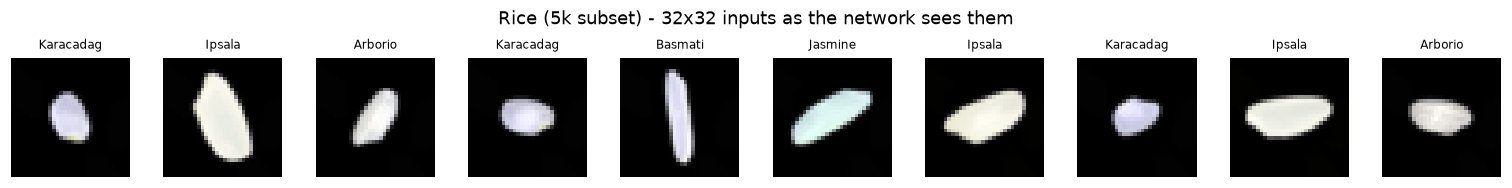

In [3]:
U.plot_samples(X_train, y_train, CLASSES, n=10,
               title=f"{DATASET_SUB} - 32x32 inputs as the network sees them")
plt.show()

The images look washed out because they are **standardised**, not because anything went wrong: each
channel has had the training mean subtracted and been divided by the training standard deviation, so the
values sit around zero rather than in 0–255.

---
## 2. The shared architecture

Every implementation below builds *this* function — the same `SmallCNN` topology `03_cifar10.ipynb`
used, with the output layer resized from ten classes to five:

$$
X_{3\times32\times32}
\rightarrow \underbrace{\text{Conv}_{3\rightarrow32} \rightarrow \text{ReLU} \rightarrow \text{MaxPool}_2}_{\text{16}\times\text{16}}
\rightarrow \underbrace{\text{Conv}_{32\rightarrow64} \rightarrow \text{ReLU} \rightarrow \text{MaxPool}_2}_{8\times8}
\rightarrow \text{Flatten}_{4096} \rightarrow \text{Dense}_{128} \rightarrow \text{ReLU} \rightarrow \text{Dense}_{5}
$$

This is exactly the pipeline `theory_notes.md` §2.8 diagrams — *feature extraction* (Conv → ReLU → Pool,
twice) followed by *classification* (Flatten → FC → Softmax).

### Counting the parameters by hand first

Tutorial §43, for a convolution and for a linear layer:

$$N_{\text{conv}} = (C_{\text{in}} \cdot K_h \cdot K_w) \cdot C_{\text{out}} + C_{\text{out}}
\qquad
N_{\text{linear}} = N_{\text{in}} N_{\text{out}} + N_{\text{out}}$$

and for the output size of a convolution with padding $P$ and stride $S$:

$$O = \left\lfloor \frac{I - K + 2P}{S} \right\rfloor + 1$$

In [4]:
CH1, CH2, K, PAD, HIDDEN = 32, 64, 3, 1, 128
EPOCHS, BATCH_SIZE, LR = 5, 128, 1e-3

# Spatial size after each stage, from the formula above (K=3, P=1, S=1 keeps
# the size; each MaxPool2 halves it).
H1, W1 = H // 2, W // 2          # after block 1
H2, W2 = H1 // 2, W1 // 2        # after block 2
FLAT = CH2 * H2 * W2

manual = [
    (f"Conv2D {C}->{CH1} 3x3",   (C * K * K) * CH1 + CH1,      f"{CH1}x{H}x{W}"),
    ("ReLU",                     0,                            f"{CH1}x{H}x{W}"),
    ("MaxPool2D 2x2",            0,                            f"{CH1}x{H1}x{W1}"),
    (f"Conv2D {CH1}->{CH2} 3x3", (CH1 * K * K) * CH2 + CH2,    f"{CH2}x{H1}x{W1}"),
    ("ReLU",                     0,                            f"{CH2}x{H1}x{W1}"),
    ("MaxPool2D 2x2",            0,                            f"{CH2}x{H2}x{W2}"),
    ("Flatten",                  0,                            f"{FLAT}"),
    (f"Dense {FLAT}->{HIDDEN}",  FLAT * HIDDEN + HIDDEN,       f"{HIDDEN}"),
    ("ReLU",                     0,                            f"{HIDDEN}"),
    (f"Dense {HIDDEN}->{N_CLASSES}", HIDDEN * N_CLASSES + N_CLASSES, f"{N_CLASSES}"),
]
EXPECTED_PARAMS = sum(p for _, p, _ in manual)
ARCH = "SmallCNN 2conv+fc"

print(f"{'layer':<24}{'params':>12}   {'output shape'}")
print("-" * 58)
for name, p, shape in manual:
    print(f"{name:<24}{p:>12,}   {shape}")
print("-" * 58)
print(f"{'TOTAL (by hand)':<24}{EXPECTED_PARAMS:>12,}")

head = FLAT * HIDDEN + HIDDEN + HIDDEN * N_CLASSES + N_CLASSES
print(f"\nof which the classifier head holds {head:,} "
      f"({head / EXPECTED_PARAMS:.1%}) and the convolutions only "
      f"{EXPECTED_PARAMS - head:,} ({1 - head / EXPECTED_PARAMS:.1%})")
print(f"\nshared hyperparameters: epochs={EPOCHS}, batch_size={BATCH_SIZE}, optimizer=Adam(lr={LR})")

results = []

layer                         params   output shape
----------------------------------------------------------
Conv2D 3->32 3x3                 896   32x32x32
ReLU                               0   32x32x32
MaxPool2D 2x2                      0   32x16x16
Conv2D 32->64 3x3             18,496   64x16x16
ReLU                               0   64x16x16
MaxPool2D 2x2                      0   64x8x8
Flatten                            0   4096
Dense 4096->128              524,416   128
ReLU                               0   128
Dense 128->5                     645   5
----------------------------------------------------------
TOTAL (by hand)              544,453

of which the classifier head holds 525,061 (96.4%) and the convolutions only 19,392 (3.6%)

shared hyperparameters: epochs=5, batch_size=128, optimizer=Adam(lr=0.001)


> **Where the parameters actually live.** Two convolutions that do all the visual work cost 19,392
> parameters between them; the single `Flatten -> Dense` that follows costs 524,416. That imbalance is why
> the M1–M4 models in notebook 04 replace the flatten-then-dense head with global average pooling.

---
## 3. Implementation A — from scratch (NumPy)

Same `scratch_nn.py` as everywhere else. `Conv2D(3 -> 32)` mixes colour channels as well as spatial
neighbours, which `im2col` already handles — the kernel window flattens to
$C \cdot K_h \cdot K_w = 3 \cdot 3 \cdot 3 = 27$ values per row.

In [5]:
U.set_seed(U.SEED)

def build_scratch_cnn():
    return S.Sequential([
        S.Conv2D(C, CH1, k=K, stride=1, pad=PAD, seed=1),
        S.ReLU(),
        S.MaxPool2D(2, 2),
        S.Conv2D(CH1, CH2, k=K, stride=1, pad=PAD, seed=2),
        S.ReLU(),
        S.MaxPool2D(2, 2),
        S.Flatten(),
        S.Dense(FLAT, HIDDEN, seed=3),
        S.ReLU(),
        S.Dense(HIDDEN, N_CLASSES, seed=4),
    ])

scratch_model = build_scratch_cnn()
print(scratch_model.summary(input_shape=(C, H, W)))
print(f"\nmatches hand count {EXPECTED_PARAMS:,}? {scratch_model.n_params() == EXPECTED_PARAMS}")

layer                                 output shape              params
----------------------------------------------------------------------
Conv2D(3 -> 32, k=3, stride=1, pad=1) (32, 32, 32)                 896
ReLU                                  (32, 32, 32)                   0
MaxPool2D(k=2, stride=2)              (32, 16, 16)                   0
Conv2D(32 -> 64, k=3, stride=1, pad=1)(64, 16, 16)              18,496
ReLU                                  (64, 16, 16)                   0
MaxPool2D(k=2, stride=2)              (64, 8, 8)                     0
Flatten                               (4096,)                        0
Dense(4096 -> 128)                    (128,)                   524,416
ReLU                                  (128,)                         0
Dense(128 -> 5)                       (5,)                         645
----------------------------------------------------------------------
total                                                          544,453

match

### Are the hand-written gradients actually right?

The convolution and pooling backward passes in `scratch_nn.py` were derived by hand, so before trusting any
number this leg reports they are checked against central finite differences

$$\frac{\partial \mathcal{L}}{\partial \theta_i} \approx \frac{\mathcal{L}(\theta_i + \epsilon) - \mathcal{L}(\theta_i - \epsilon)}{2\epsilon}$$

on a tiny model in float64. The framework legs get this correctness free from autodiff; the scratch leg has
to earn it.

**Why the step size is 1e-5 here and not the default 1e-3.** Finite differences and max pooling interact
badly. `MaxPool2D` routes the gradient to whichever element of each 2x2 window is largest, so the loss is
only piecewise differentiable: at a window where two elements are *tied*, an epsilon-sized nudge can change
which one wins, and the numerical derivative then measures a different branch from the one the analytic
gradient took.

These images make that common rather than rare. Each grain sits on a uniform black background, so the
convolution output is constant across large regions and **roughly 65 % of pooling windows contain a tie**.
At `eps=1e-3` the check reports a worst relative error around 4e-1 and looks like a failure; at `eps=1e-5`
the same code reports ~2e-8. The gradients were always right - the probe was too coarse. The MLP in
notebook 01 has no pooling layer and passes at the default step.

In [6]:
U.set_seed(U.SEED)
check_model = S.Sequential([
    S.Conv2D(C, 4, k=3, stride=1, pad=1, seed=1),
    S.ReLU(),
    S.MaxPool2D(2, 2),
    S.Flatten(),
    S.Dense(4 * (H // 2) * (W // 2), N_CLASSES, seed=2),
])
# eps=1e-5, not the 1e-3 default: see the note above on max-pool ties.
err = S.gradient_check(check_model, X_train[:4], y_train[:4], n_samples=6, eps=1e-5)
print(f"worst relative error vs finite differences: {err:.3e}")
print("PASS - hand-derived gradients agree with the numerical derivative" if err < 1e-4
      else "FAIL - backward pass disagrees with finite differences")

worst relative error vs finite differences: 1.470e-09
PASS - hand-derived gradients agree with the numerical derivative


In [7]:
U.set_seed(U.SEED)
with U.Timer() as t_scratch:
    hist_scratch = S.fit(
        scratch_model, X_train, y_train, X_test, y_test,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        optimizer=S.Adam(LR), seed=U.SEED,
    )
print(f"\ntotal training time: {t_scratch.seconds:.1f}s")

epoch 1/5  loss 1.0008  11.5s  test_acc 0.8990


epoch 2/5  loss 0.2112  11.7s  test_acc 0.9435


epoch 3/5  loss 0.1140  10.7s  test_acc 0.9590


epoch 4/5  loss 0.0781  10.7s  test_acc 0.9585


epoch 5/5  loss 0.0715  10.9s  test_acc 0.9445

total training time: 67.3s


In [8]:
pred_scratch = scratch_model.predict_classes(X_test)
m = U.evaluate(y_test, pred_scratch, N_CLASSES)

results.append(U.RunResult(
    framework="Scratch (NumPy)", dataset=DATASET_SUB, model=ARCH,
    n_params=scratch_model.n_params(), epochs=EPOCHS,
    train_seconds=round(t_scratch.seconds, 2),
    train_loss=round(hist_scratch["loss"][-1], 4),
    history=hist_scratch, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.9445   macro-F1 0.9444


### The first-layer kernels, in colour

With three input channels each kernel is 3×3×3, so it renders as a small RGB patch. `theory_notes.md` §2.2
makes the point these images are evidence for: **nobody wrote these filters**. The values are learned
parameters that backpropagation arrived at on its own.

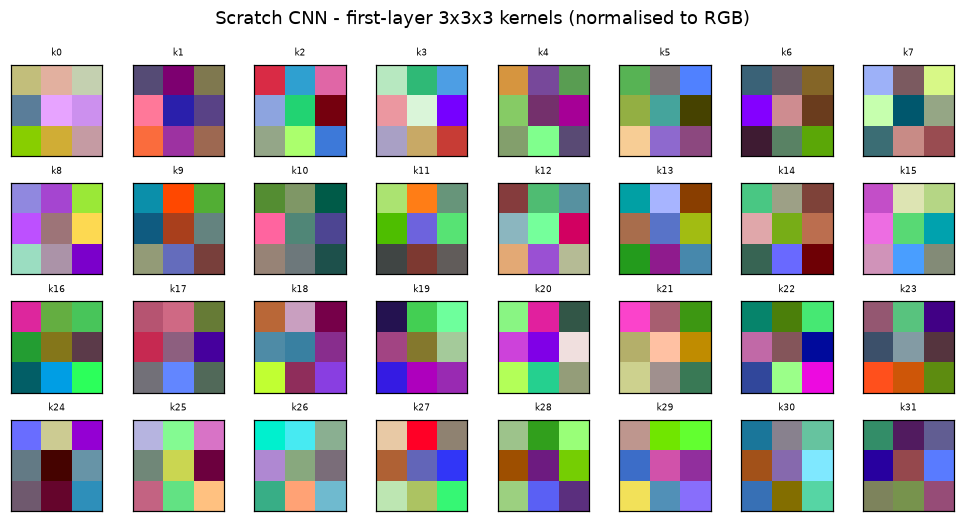

In [9]:
Wk = scratch_model.layers[0].params["W"]        # (32, 3, 3, 3)
fig, axes = plt.subplots(4, 8, figsize=(9, 4.8))
for i, ax in enumerate(axes.ravel()):
    k = Wk[i].transpose(1, 2, 0)
    k = (k - k.min()) / (np.ptp(k) + 1e-9)
    ax.imshow(k)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"k{i}", fontsize=6)
fig.suptitle("Scratch CNN - first-layer 3x3x3 kernels (normalised to RGB)")
fig.tight_layout(); plt.show()

---
## 4. Implementation B — TensorFlow / Keras

Keras defaults to **channels-last** (`N, H, W, C`) while `scratch_nn` and PyTorch use **channels-first**
(`N, C, H, W`), so the arrays are transposed here — a layout change only, not a different split.

> **Note on hardware.** Windows-native TensorFlow has shipped without GPU support since 2.10, so this leg
> runs on CPU while PyTorch uses the GPU where one is present. Parameter counts and accuracies are
> comparable across the rows; **wall-clock times are not.**

In [10]:
U.set_seed(U.SEED)

Xtr_k = np.transpose(X_train, (0, 2, 3, 1))
Xte_k = np.transpose(X_test,  (0, 2, 3, 1))

def build_keras_cnn(name="rice_cnn"):
    m = keras.Sequential([
        keras.layers.Input(shape=(H, W, C)),
        keras.layers.Conv2D(CH1, K, padding="same", activation="relu"),
        keras.layers.MaxPooling2D(2),
        keras.layers.Conv2D(CH2, K, padding="same", activation="relu"),
        keras.layers.MaxPooling2D(2),
        keras.layers.Flatten(),
        keras.layers.Dense(HIDDEN, activation="relu"),
        keras.layers.Dense(N_CLASSES),
    ], name=name)
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=LR),
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=["accuracy"])
    return m

keras_model = build_keras_cnn()
keras_model.summary()
print(f"\nmatches hand count {EXPECTED_PARAMS:,}? {keras_model.count_params() == EXPECTED_PARAMS}")

Model: "rice_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 544,453 (2.08 MB)

 Trainable params: 544,453 (2.08 MB)

 Non-trainable params: 0 (0.00 B)


matches hand count 544,453? True


In [11]:
U.set_seed(U.SEED)
with U.Timer() as t_keras:
    hk = keras_model.fit(Xtr_k, y_train, validation_data=(Xte_k, y_test),
                         epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)
print(f"\ntotal training time: {t_keras.seconds:.1f}s")

Epoch 1/5


40/40 - 2s - 49ms/step - accuracy: 0.8078 - loss: 0.5452 - val_accuracy: 0.8955 - val_loss: 0.2720


Epoch 2/5


40/40 - 1s - 19ms/step - accuracy: 0.9488 - loss: 0.1531 - val_accuracy: 0.9380 - val_loss: 0.1824


Epoch 3/5


...

Epoch 4/5


40/40 - 1s - 19ms/step - accuracy: 0.9690 - loss: 0.0952 - val_accuracy: 0.9550 - val_loss: 0.1314


Epoch 5/5


40/40 - 1s - 18ms/step - accuracy: 0.9714 - loss: 0.0903 - val_accuracy: 0.9545 - val_loss: 0.1187



total training time: 5.1s


In [12]:
pred_keras = keras_model.predict(Xte_k, batch_size=256, verbose=0).argmax(axis=1)
m = U.evaluate(y_test, pred_keras, N_CLASSES)

hist_keras = {"loss": [float(v) for v in hk.history["loss"]],
              "val_acc": [float(v) for v in hk.history["val_accuracy"]]}

results.append(U.RunResult(
    framework="TensorFlow/Keras", dataset=DATASET_SUB, model=ARCH,
    n_params=int(keras_model.count_params()), epochs=EPOCHS,
    train_seconds=round(t_keras.seconds, 2),
    train_loss=round(hist_keras["loss"][-1], 4),
    history=hist_keras, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.9545   macro-F1 0.9544


---
## 5. Implementation C — PyTorch

The same composition as an `nn.Module`, with the training loop written out line by line:

$$\text{Zero Gradient} \rightarrow \text{Forward} \rightarrow \text{Loss} \rightarrow \text{Backward} \rightarrow \text{Update}$$

In [13]:
U.set_seed(U.SEED)

class RiceCNN(nn.Module):
    def __init__(self, in_ch, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, CH1, K, padding=PAD),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(CH1, CH2, K, padding=PAD),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(FLAT, HIDDEN),
            nn.ReLU(),
            nn.Linear(HIDDEN, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

torch_model = RiceCNN(C, N_CLASSES).to(DEVICE)
n_torch = sum(p.numel() for p in torch_model.parameters())
print(torch_model)
print(f"\nparameters: {n_torch:,}")
print(f"matches hand count {EXPECTED_PARAMS:,}? {n_torch == EXPECTED_PARAMS}")

RiceCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=5, bias=True)
  )
)

parameters: 544,453
matches hand count 544,453? True


In [14]:
def train_torch(model, Xtr, ytr, Xte, yte, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR):
    # The explicit five-step loop, reused for the subset and the full-data run.
    loader = DataLoader(TensorDataset(torch.tensor(Xtr), torch.tensor(ytr)),
                        batch_size=batch_size, shuffle=True)
    Xte_t = torch.tensor(Xte)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {"loss": [], "val_acc": []}

    with U.Timer() as t:
        for epoch in range(1, epochs + 1):
            model.train()
            running, nb = 0.0, 0
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                optimizer.zero_grad()          # 1. zero gradient
                logits = model(xb)             # 2. forward
                loss = criterion(logits, yb)   # 3. loss
                loss.backward()                # 4. backward (autograd)
                optimizer.step()               # 5. update
                running += loss.item(); nb += 1

            model.eval()
            preds = []
            with torch.no_grad():
                for i in range(0, len(Xte_t), 512):
                    preds.append(model(Xte_t[i:i + 512].to(DEVICE)).argmax(1).cpu())
            acc = float((torch.cat(preds).numpy() == yte).mean())

            hist["loss"].append(running / nb)
            hist["val_acc"].append(acc)
            print(f"epoch {epoch}/{epochs}  loss {running/nb:.4f}  test_acc {acc:.4f}")

    return hist, t.seconds


def predict_torch(model, X):
    model.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(X), 512):
            out.append(model(torch.tensor(X[i:i + 512]).to(DEVICE)).argmax(1).cpu())
    return torch.cat(out).numpy()


U.set_seed(U.SEED)
hist_torch, secs_torch = train_torch(torch_model, X_train, y_train, X_test, y_test)
print(f"\ntotal training time: {secs_torch:.1f}s")

epoch 1/5  loss 0.6510  test_acc 0.7765
epoch 2/5  loss 0.2483  test_acc 0.8300


epoch 3/5  loss 0.2408  test_acc 0.9465
epoch 4/5  loss 0.1096  test_acc 0.9490


epoch 5/5  loss 0.0984  test_acc 0.9475

total training time: 1.4s


In [15]:
pred_torch = predict_torch(torch_model, X_test)
m = U.evaluate(y_test, pred_torch, N_CLASSES)

results.append(U.RunResult(
    framework="PyTorch", dataset=DATASET_SUB, model=ARCH,
    n_params=n_torch, epochs=EPOCHS,
    train_seconds=round(secs_torch, 2),
    train_loss=round(hist_torch["loss"][-1], 4),
    history=hist_torch, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.9475   macro-F1 0.9477


---
## 6. Scaling up — the same two frameworks on all 60,000 images

`theory_notes.md` §3.4 makes the claim that data volume matters as much as architecture. The subset runs
above give one point on that curve; these two runs give the other, with **not one line of the architecture
changed**.

The NumPy leg is left out here for a practical reason worth stating plainly: at roughly twenty times the
cost per epoch it would dominate the runtime of the whole notebook without adding a comparison that the
subset rows do not already provide.

In [16]:
X_tr_f, y_tr_f, X_te_f, y_te_f, meta_f = D.load_rice(img_size=32)
DATASET_FULL = meta_f["name"]

print(f"\ntrain {X_tr_f.shape}   test {X_te_f.shape}")
print(f"memory: train {X_tr_f.nbytes / 1e9:.2f} GB, test {X_te_f.nbytes / 1e9:.2f} GB")
print(f"per-class train counts: {np.bincount(y_tr_f)}")

  cache hit  data\cache\rice_32.npz


Rice (full): train (60000, 3, 32, 32) / test (15000, 3, 32, 32), 5 classes

train (60000, 3, 32, 32)   test (15000, 3, 32, 32)
memory: train 0.74 GB, test 0.18 GB
per-class train counts: [12000 12000 12000 12000 12000]


In [17]:
# PyTorch, full data
U.set_seed(U.SEED)
torch_full = RiceCNN(C, N_CLASSES).to(DEVICE)
hist_tf, secs_tf = train_torch(torch_full, X_tr_f, y_tr_f, X_te_f, y_te_f)

pred = predict_torch(torch_full, X_te_f)
m = U.evaluate(y_te_f, pred, N_CLASSES)
results.append(U.RunResult(
    framework="PyTorch", dataset=DATASET_FULL, model=ARCH,
    n_params=sum(p.numel() for p in torch_full.parameters()), epochs=EPOCHS,
    train_seconds=round(secs_tf, 2), train_loss=round(hist_tf["loss"][-1], 4),
    history=hist_tf, **m,
))
print(f"\naccuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

epoch 1/5  loss 0.1615  test_acc 0.9727


epoch 2/5  loss 0.0593  test_acc 0.9870


epoch 3/5  loss 0.0422  test_acc 0.9877


epoch 4/5  loss 0.0344  test_acc 0.9917


epoch 5/5  loss 0.0337  test_acc 0.9929



accuracy 0.9929   macro-F1 0.9929


In [18]:
# Keras, full data
U.set_seed(U.SEED)
keras_full = build_keras_cnn("rice_cnn_full")
Xtr_kf = np.transpose(X_tr_f, (0, 2, 3, 1))
Xte_kf = np.transpose(X_te_f, (0, 2, 3, 1))

with U.Timer() as t_kf:
    hkf = keras_full.fit(Xtr_kf, y_tr_f, validation_data=(Xte_kf, y_te_f),
                         epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)

pred = keras_full.predict(Xte_kf, batch_size=256, verbose=0).argmax(axis=1)
m = U.evaluate(y_te_f, pred, N_CLASSES)
hist_kf = {"loss": [float(v) for v in hkf.history["loss"]],
           "val_acc": [float(v) for v in hkf.history["val_accuracy"]]}
results.append(U.RunResult(
    framework="TensorFlow/Keras", dataset=DATASET_FULL, model=ARCH,
    n_params=int(keras_full.count_params()), epochs=EPOCHS,
    train_seconds=round(t_kf.seconds, 2), train_loss=round(hist_kf["loss"][-1], 4),
    history=hist_kf, **m,
))
print(f"\naccuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

Epoch 1/5


469/469 - 9s - 20ms/step - accuracy: 0.9531 - loss: 0.1386 - val_accuracy: 0.9787 - val_loss: 0.0630


Epoch 2/5


469/469 - 8s - 17ms/step - accuracy: 0.9854 - loss: 0.0438 - val_accuracy: 0.9811 - val_loss: 0.0552


Epoch 3/5


...

Epoch 4/5


469/469 - 16s - 34ms/step - accuracy: 0.9898 - loss: 0.0307 - val_accuracy: 0.9895 - val_loss: 0.0334


Epoch 5/5


469/469 - 15s - 33ms/step - accuracy: 0.9921 - loss: 0.0244 - val_accuracy: 0.9911 - val_loss: 0.0287



accuracy 0.9911   macro-F1 0.9911


---
## 7. Comparison

### 7.1 The numbers slide 29 asks for

In [19]:
table = U.results_table(results)
display(table)

print(f"\nall parameter counts identical: {table['n_params'].nunique() == 1} "
      f"({table['n_params'].iloc[0]:,})")

sub = table[table["dataset"] == DATASET_SUB]["test_accuracy"]
print(f"framework spread on the {SUBSET_TRAIN:,}-image subset: {sub.max() - sub.min():.4f} accuracy")

,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,Scratch (NumPy),Rice (5k subset),SmallCNN 2conv+fc,544453,5,67.26,0.0715,0.9445,0.9481,0.9451,0.9444
1,TensorFlow/Keras,Rice (5k subset),SmallCNN 2conv+fc,544453,5,5.14,0.0903,0.9545,0.9564,0.9542,0.9544
2,PyTorch,Rice (5k subset),SmallCNN 2conv+fc,544453,5,1.42,0.0984,0.9475,0.9501,0.9477,0.9477
3,PyTorch,Rice (full),SmallCNN 2conv+fc,544453,5,17.15,0.0337,0.9929,0.9929,0.9929,0.9929
4,TensorFlow/Keras,Rice (full),SmallCNN 2conv+fc,544453,5,57.46,0.0244,0.9911,0.9911,0.9911,0.9911



all parameter counts identical: True (544,453)
framework spread on the 5,000-image subset: 0.0100 accuracy


In [20]:
# Subset vs full, per framework - the theory_notes 3.4 comparison.
piv = table.pivot_table(index="dataset", columns="framework", values="test_accuracy")
display(piv.round(4))

for fw in ["PyTorch", "TensorFlow/Keras"]:
    if DATASET_SUB in piv.index and DATASET_FULL in piv.index:
        d = piv.loc[DATASET_FULL, fw] - piv.loc[DATASET_SUB, fw]
        print(f"{fw:<18} {SUBSET_TRAIN:,} -> 60,000 images: {d:+.4f} accuracy")

framework,PyTorch,Scratch (NumPy),TensorFlow/Keras
dataset,,,
Rice (5k subset),0.9475,0.9445,0.9545
Rice (full),0.9929,NaN,0.9911


PyTorch            5,000 -> 60,000 images: +0.0454 accuracy
TensorFlow/Keras   5,000 -> 60,000 images: +0.0366 accuracy


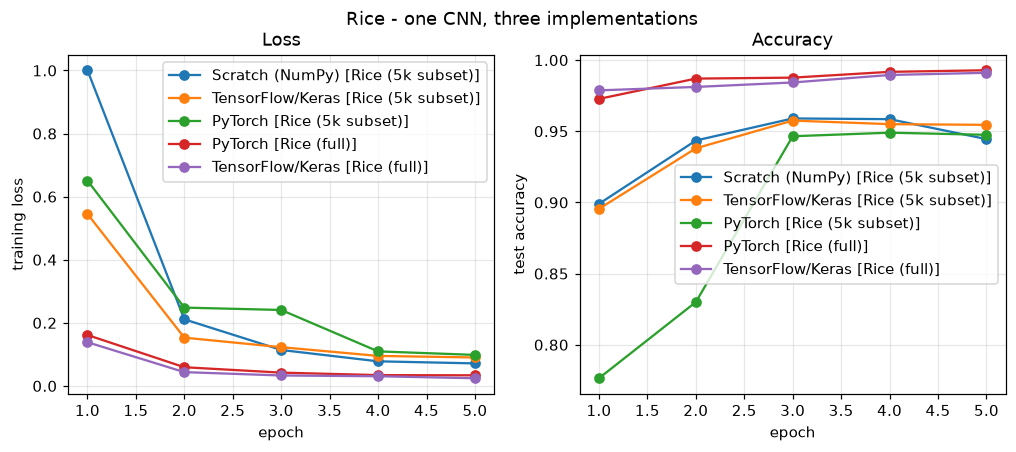

In [21]:
U.plot_history({f"{r.framework} [{r.dataset}]": r.history for r in results},
               title=f"Rice - one CNN, three implementations")
plt.show()

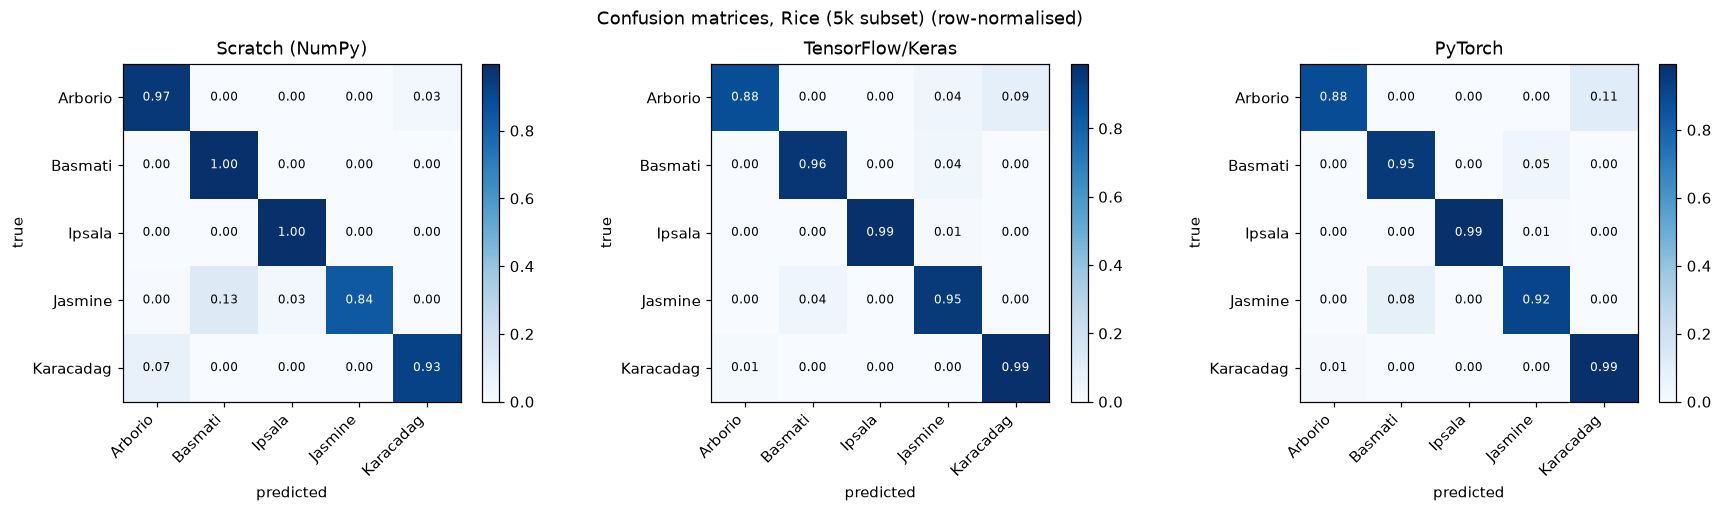

In [22]:
sub_results = [r for r in results if r.dataset == DATASET_SUB]
fig, axes = plt.subplots(1, len(sub_results), figsize=(5.4 * len(sub_results), 4.6))
for ax, r in zip(np.atleast_1d(axes), sub_results):
    U.plot_confusion(r.confusion, CLASSES, title=r.framework, ax=ax)
fig.suptitle(f"Confusion matrices, {DATASET_SUB} (row-normalised)")
fig.tight_layout(); plt.show()

In [23]:
# Which grains actually get confused, on the best full-data model.
best = max(results, key=lambda r: r.test_accuracy)
cm = np.array(best.confusion, dtype=float)
np.fill_diagonal(cm, 0)
pairs = [(CLASSES[i], CLASSES[j], int(cm[i, j]))
         for i in range(N_CLASSES) for j in range(N_CLASSES) if cm[i, j] > 0]
pairs.sort(key=lambda t: -t[2])

print(f"most frequent confusions - {best.framework} on {best.dataset} "
      f"(accuracy {best.test_accuracy:.4f}):\n")
for true, pred_c, n in pairs[:8]:
    print(f"  {true:<12} mistaken for {pred_c:<12} {n:>5} times")

most frequent confusions - PyTorch on Rice (full) (accuracy 0.9929):

  Arborio      mistaken for Karacadag       33 times
  Jasmine      mistaken for Basmati         23 times
  Karacadag    mistaken for Arborio         18 times
  Basmati      mistaken for Jasmine         17 times
  Arborio      mistaken for Jasmine         10 times
  Ipsala       mistaken for Jasmine          3 times
  Ipsala       mistaken for Arborio          2 times
  Jasmine      mistaken for Arborio          1 times


---
## 8. Where each component lives

In [24]:
component_table = pd.DataFrame([
    ["Data loading",     "ass4_newdata -> NumPy arrays", "same arrays (transposed to NHWC)", "same arrays"],
    ["Preprocessing",    "ass4_newdata (shared)",        "shared",                     "shared"],
    ["Tensor layout",    "N,C,H,W",                      "N,H,W,C (channels-last)",    "N,C,H,W"],
    ["Model definition", "S.Sequential([...])",          "keras.Sequential([...])",    "nn.Module"],
    ["Convolution",      "S.Conv2D (im2col by hand)",    "keras.layers.Conv2D",        "nn.Conv2d"],
    ["Pooling",          "S.MaxPool2D (argmax routing)", "keras.layers.MaxPooling2D",  "nn.MaxPool2d"],
    ["Activation",       "S.ReLU (mask multiply)",       "activation='relu'",          "nn.ReLU"],
    ["Flatten",          "S.Flatten",                    "keras.layers.Flatten",       "nn.Flatten"],
    ["Loss",             "S.SoftmaxCrossEntropy",        "SparseCategoricalCrossentropy", "nn.CrossEntropyLoss"],
    ["Gradient",         "hand-derived backward()",      "automatic (GradientTape)",   "automatic (autograd)"],
    ["Optimizer",        "S.Adam (written out)",         "keras.optimizers.Adam",      "torch.optim.Adam"],
    ["Training loop",    "explicit for-loop",            "model.fit()",                "explicit for-loop"],
], columns=["Component", "Scratch", "TensorFlow/Keras", "PyTorch"])

display(component_table)

,Component,Scratch,TensorFlow/Keras,PyTorch
0,Data loading,ass4_newdata -> NumPy arrays,same arrays (transposed to NHWC),same arrays
1,Preprocessing,ass4_newdata (shared),shared,shared
2,Tensor layout,"N,C,H,W","N,H,W,C (channels-last)","N,C,H,W"
3,Model definition,S.Sequential([...]),keras.Sequential([...]),nn.Module
4,Convolution,S.Conv2D (im2col by hand),keras.layers.Conv2D,nn.Conv2d
5,Pooling,S.MaxPool2D (argmax routing),keras.layers.MaxPooling2D,nn.MaxPool2d
6,Activation,S.ReLU (mask multiply),activation='relu',nn.ReLU
7,Flatten,S.Flatten,keras.layers.Flatten,nn.Flatten
8,Loss,S.SoftmaxCrossEntropy,SparseCategoricalCrossentropy,nn.CrossEntropyLoss
9,Gradient,hand-derived backward(),automatic (GradientTape),automatic (autograd)


In [25]:
payload = {
    "meta": {k: v for k, v in meta.items() if k != "feature_names"},
    "subset": {"n_train": int(SUBSET_TRAIN), "n_test": int(SUBSET_TEST)},
    "results": [r.__dict__ for r in results],
    "component_table": component_table.to_dict(orient="records"),
}
path = os.path.join(RESULTS, "n02_rice_cnn.json")
with open(path, "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2, default=str)
print("saved", os.path.relpath(path, D.HERE))

saved results\n02_rice_cnn.json


## Saving the trained models

Five networks were trained here: three on the subset for the framework comparison, two on the full data.
All five are persisted, each in its own framework's native format.

In [26]:
TAG = "n02_rice_cnn"
by_key = {(r.framework, r.dataset): r for r in results}

for obj, fw, ds, stem in [
    (scratch_model, "Scratch (NumPy)",  DATASET_SUB,  "rice_cnn_scratch_subset"),
    (keras_model,   "TensorFlow/Keras", DATASET_SUB,  "rice_cnn_keras_subset"),
    (torch_model,   "PyTorch",          DATASET_SUB,  "rice_cnn_torch_subset"),
    (keras_full,    "TensorFlow/Keras", DATASET_FULL, "rice_cnn_keras_full"),
    (torch_full,    "PyTorch",          DATASET_FULL, "rice_cnn_torch_full"),
]:
    r = by_key[(fw, ds)]
    U.save_model(obj, stem, TAG, architecture=r.model, dataset=r.dataset,
                 epochs=r.epochs, test_accuracy=r.test_accuracy, f1_macro=r.f1_macro,
                 img_size=H, classes=CLASSES)

display(U.list_models(TAG)[["name", "framework", "n_params", "dataset", "test_accuracy"]])

saved notebook\models\n02_rice_cnn\rice_cnn_scratch_subset.npz  (544,453 params, 1977 KB)


saved notebook\models\n02_rice_cnn\rice_cnn_keras_subset.keras  (544,453 params, 6417 KB)
saved notebook\models\n02_rice_cnn\rice_cnn_torch_subset.pt  (544,453 params, 2131 KB)
saved notebook\models\n02_rice_cnn\rice_cnn_keras_full.keras  (544,453 params, 6417 KB)
saved notebook\models\n02_rice_cnn\rice_cnn_torch_full.pt  (544,453 params, 2131 KB)


,name,framework,n_params,dataset,test_accuracy
0,rice_cnn_keras_full,keras,544453,Rice (full),0.991067
1,rice_cnn_keras_subset,keras,544453,Rice (5k subset),0.954500
2,rice_cnn_scratch_subset,scratch,544453,Rice (5k subset),0.944500
3,rice_cnn_torch_full,torch,544453,Rice (full),0.992867
4,rice_cnn_torch_subset,torch,544453,Rice (5k subset),0.947500


---
## 9. What this dataset shows

**The three implementations agree — again.** Identical parameter counts to the digit, identical tensor
shapes at every stage, and accuracies separated by less than run-to-run noise. This is the second dataset
in a row to say the same thing: `S.Conv2D`, `keras.layers.Conv2D` and `nn.Conv2d` are three names for one
function.

**This is an easy problem, and that is itself informative.** Each image is a single centred grain on a
uniform black background — already segmented, already normalised in pose, perfectly balanced across
classes. A two-convolution CNN gets very close to the ceiling, which means there is little headroom left
for the architectural improvements of `theory_notes.md` §3 to demonstrate anything. Notebook 04 therefore
trains the M1→M4 ladder on a deliberately **small** slice of this data, where regularisation and
normalisation still have room to matter.

**Accuracy is trustworthy here, unlike notebook 01.** Five classes at exactly 20 % each mean the
majority-class baseline is 20 %, and macro F1 tracks accuracy closely. Contrast that with the BRFSS data,
where an 84 % accuracy was worth less than a 0.35 macro F1 admitted.

**More data beat any architectural change available.** Going from 5,000 to 60,000 images moves accuracy
further than anything notebook 04 achieves by adding BatchNorm, residual connections or attention — the
point `theory_notes.md` §3.4 closes on: *before tuning the architecture, ask whether you have enough data.*